# DLinear Baseline — Unimodal Numerical

Exact same data pipeline as `time-mmd-new-beginning_stable_` (V17).

- **Data**: MM-TSFlib `US_FLURATIO_Week.csv`
- **Lookback**: 36 weeks | **Horizon**: 12 weeks
- **Split**: 80 / 10 / 10 chronological
- **Model**: DLinear (channel-independent, trend + seasonal decomposition)
- **Target**: OT (% weighted ILI)

> Update `DATA_PATH` and `LOG_DIR` in Section 2 before running.

## 1. Dependencies

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import joblib
import numpy as np
import pandas as pd
import torch
import random
import matplotlib as mpl
from matplotlib.patches import Patch
import torch.nn as nn
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 2. Config — Edit paths here

In [2]:
# ── Edit these two paths ──────────────────────────────────────────────────────
DATA_PATH = '/kaggle/input/datasets/mohammadhossein77/ili-data/US_FLURATIO_Week.csv'
LOG_DIR = '/kaggle/working/logs'
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs(LOG_DIR, exist_ok=True)

LOOKBACK = 36
HORIZON = 12
BATCH_SIZE = 16    # DLinear is lightweight; bigger batches are fine
EPOCHS = 100
PATIENCE = 15
LR = 1e-3
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## 3. Data Loading & Feature Engineering

Identical to `time-mmd-new-beginning_stable_` cells 20–63.

In [3]:
df = pd.read_csv(DATA_PATH)
print(f'Raw shape: {df.shape}')
df.head(3)

Raw shape: (1389, 25)


,date,start_date,end_date,REGION TYPE,REGION,YEAR,WEEK,% WEIGHTED ILI,OT,AGE 0-4,...,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS,YEAR_WEEK,prior_history_avg,prior_history_std,Final_Search_2,Final_Search_4,Final_Search_6,Final_Output
0,9/29/1997,9/29/1997,10/5/1997,National,X,1997,40,1.10148,1.21686,179,...,570,192,46842,1997-40,0.0,0.0,Available facts are as follows: 1997-09-22: Za...,Available facts are as follows: 1997-09-22: Za...,Available facts are as follows: 1997-09-22: Za...,"Based on the provided textual information, I p..."
1,10/6/1997,10/6/1997,10/12/1997,National,X,1997,41,1.20007,1.28064,199,...,615,191,48023,1997-41,0.0,0.0,Available facts are as follows: 1997-09-29: Th...,Available facts are as follows: 1997-09-29: Th...,Available facts are as follows: 1997-09-29: Th...,"Based on the provided textual information, my ..."
2,10/13/1997,10/13/1997,10/19/1997,National,X,1997,42,1.37876,1.23906,228,...,681,219,54961,1997-42,0.0,0.0,Available facts are as follows: 1997-10-06: Th...,Available facts are as follows: 1997-10-06: Th...,Available facts are as follows: 1997-10-06: Th...,"Based on the available textual information, I ..."


In [4]:
# Keep only numerical columns (drop last 4 text cols)
numeric_df = df.iloc[:, :-4].copy()

# Date parsing
numeric_df.drop(['date'], axis=1, inplace=True, errors='ignore')
numeric_df['start_date'] = pd.to_datetime(numeric_df['start_date'])
numeric_df['end_date'] = pd.to_datetime(numeric_df['end_date'])

# Cyclic week encoding — same as stable nb cell 49
numeric_df['WEEK_sin'] = np.sin(2 * np.pi * (numeric_df['WEEK'] / 52))
numeric_df['WEEK_cos'] = np.cos(2 * np.pi * (numeric_df['WEEK'] / 52))
numeric_df.drop(['WEEK'], axis=1, inplace=True)

# Drop redundant columns — stable nb cells 54 & 57
numeric_df.drop(['REGION TYPE', 'REGION', 'YEAR_WEEK'], axis=1, inplace=True, errors='ignore')
numeric_df.drop(['prior_history_std', 'prior_history_avg'], axis=1, inplace=True, errors='ignore')

# Replace X with NaN, coerce to numeric — stable nb cells 61-63
numeric_df = numeric_df.replace('X', np.nan)

num_features = [
    'YEAR', 'WEEK_sin', 'WEEK_cos',
    '% WEIGHTED ILI',
    'AGE 0-4', 'AGE 5-24',
    'AGE 25-49', 'AGE 25-64', 'AGE 50-64', 'AGE 65',
    'ILITOTAL', 'NUM. OF PROVIDERS', 'TOTAL PATIENTS'
]
numeric_df[num_features] = numeric_df[num_features].apply(pd.to_numeric, errors='coerce')

print(f'Processed shape: {numeric_df.shape}')
print(numeric_df.isna().sum())

Processed shape: (1389, 16)
start_date             0
end_date               0
YEAR                   0
% WEIGHTED ILI         0
OT                     0
AGE 0-4                0
AGE 25-49            532
AGE 25-64            762
AGE 5-24               0
AGE 50-64            532
AGE 65                 0
ILITOTAL               0
NUM. OF PROVIDERS      0
TOTAL PATIENTS         0
WEEK_sin               0
WEEK_cos               0
dtype: int64


## 4. Chronological Split  (80 / 10 / 10)

In [5]:
numeric_df.sort_values('start_date', inplace=True)

n = len(numeric_df)
train_size = int(n * 0.8)
val_size = int(n * 0.1)

train_df = numeric_df.iloc[:train_size].copy()
val_df = numeric_df.iloc[train_size : train_size + val_size].copy()
test_df = numeric_df.iloc[train_size + val_size:].copy()

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Train: 1111 | Val: 138 | Test: 140


In [6]:
# # here we should add the cylic featuers

# # New cyclic features ....
# def add_trend_features(df):
#     df = df.copy()
#     # # 1. Week-over-week change
#     # df["OT_diff_1"] = df["OT"].diff() # positive -> outbreak increasing (Vice-Versa)
    
#     # # 2. Rooling average of OT rate
#     # df["OT_roll_mean_3"] = df["OT"].rolling(window=3).mean()
#     df["OT_roll_mean_36"] = df["OT"].rolling(window=36).mean()
    
#     # # 3. Rooling standard deviation of OT rate
#     # df["OT_roll_std_3"] = df["OT"].rolling(window=3).std()
#     df["OT_roll_std_36"] = df["OT"].rolling(window=36).std()
    
#     # # 4. Momentun rate
#     # df["OT_momentum_3"] = df["OT"] - df["OT"].shift(3)
#     # df["OT_momentum_6"] = df["OT"] - df["OT"].shift(6)

#     # # 5. Relative Surge Feature
#     # df["OT_relative_6"] = (df["OT"] / df["OT_roll_mean_6"] + 1e-6) ## to not introduce new feature, I decided to rewrite it
#     # df["OT_relative_6"] = (df["OT"] / (df["OT"].rooling(window=6).mean() + 1e-6)) 

#     # # 6. Acceleration feature
#     # df["OT_acceleration"] = df["OT_diff_1"].diff(1) 
#     df = df.fillna(0)

#     return df

 

In [7]:
# # Update -------------------------
# train_df = add_trend_features(train_df)
# val_df = add_trend_features(val_df)
# test_df = add_trend_features(test_df)



In [8]:
# num_features.extend(["OT_roll_mean_36", "OT_roll_std_36"])
num_features

['YEAR',
 'WEEK_sin',
 'WEEK_cos',
 '% WEIGHTED ILI',
 'AGE 0-4',
 'AGE 5-24',
 'AGE 25-49',
 'AGE 25-64',
 'AGE 50-64',
 'AGE 65',
 'ILITOTAL',
 'NUM. OF PROVIDERS',
 'TOTAL PATIENTS']

## 5. AGE Imputation

Post-split, pre-scale — identical to stable nb cell 67.

In [9]:
for dff in [train_df, val_df, test_df]:
    # AGE 25-49 & 50-64 missing but 25-64 present -> split
    mask_split = (dff['AGE 25-49'].isna() & dff['AGE 50-64'].isna() & ~dff['AGE 25-64'].isna())
    dff.loc[mask_split, 'AGE 25-49'] = dff.loc[mask_split, 'AGE 25-64'] * 0.6
    dff.loc[mask_split, 'AGE 50-64'] = dff.loc[mask_split, 'AGE 25-64'] * 0.4

    # 25-64 missing but parts present -> combine
    mask_comb = (~dff['AGE 25-49'].isna() & ~dff['AGE 50-64'].isna() & dff['AGE 25-64'].isna())
    dff.loc[mask_comb, 'AGE 25-64'] = dff.loc[mask_comb, 'AGE 25-49'] + dff.loc[mask_comb, 'AGE 50-64']

print('NaNs after imputation (train):')
print(train_df[num_features].isna().sum())

NaNs after imputation (train):
YEAR                 0
WEEK_sin             0
WEEK_cos             0
% WEIGHTED ILI       0
AGE 0-4              0
AGE 5-24             0
AGE 25-49            0
AGE 25-64            0
AGE 50-64            0
AGE 65               0
ILITOTAL             0
NUM. OF PROVIDERS    0
TOTAL PATIENTS       0
dtype: int64


## 6. Scaling

Fit on train only — identical to stable nb cell 72.

In [10]:
# Feature scaler (13 features — NOT OT)
feature_scaler = MinMaxScaler()
train_df[num_features] = feature_scaler.fit_transform(train_df[num_features])
val_df[num_features]   = feature_scaler.transform(val_df[num_features])
test_df[num_features]  = feature_scaler.transform(test_df[num_features])
joblib.dump(feature_scaler, os.path.join(LOG_DIR, 'dlinear_feature_scaler.pkl'))

# Target scaler (OT only)
target_scaler = MinMaxScaler()
train_df['OT'] = target_scaler.fit_transform(train_df['OT'].values.reshape(-1, 1)).flatten()
val_df['OT'] = target_scaler.transform(val_df['OT'].values.reshape(-1, 1)).flatten()
test_df['OT'] = target_scaler.transform(test_df['OT'].values.reshape(-1, 1)).flatten()
joblib.dump(target_scaler, os.path.join(LOG_DIR, 'dlinear_target_scaler.pkl'))

# Append OT after scaling — same order as stable nb
num_features.append('OT')
print(f'Total features (incl. OT): {len(num_features)}')
# OT is the LAST column -> index -1 (OT_IDX)

Total features (incl. OT): 14


## 7. Sequence Construction

Prepend lookback tail from previous split — identical to stable nb cell 76.

In [11]:
def create_sequences(df, lookback, horizon, cols):
    """Returns X (N, lookback, C) and y (N, horizon) for OT target."""
    df = df.sort_values('start_date').reset_index(drop=True)
    X, y = [], []
    for i in range(len(df) - lookback - horizon + 1):
        X.append(df[cols].iloc[i : i + lookback].values)
        y.append(df['OT'].iloc[i + lookback : i + lookback + horizon].values)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


val_df_full = pd.concat([train_df.iloc[-LOOKBACK:], val_df], ignore_index=True)
test_df_full = pd.concat([val_df.iloc[-LOOKBACK:], test_df], ignore_index=True)

X_train, y_train = create_sequences(train_df, LOOKBACK, HORIZON, num_features)
X_val, y_val = create_sequences(val_df_full, LOOKBACK, HORIZON, num_features)
X_test, y_test = create_sequences(test_df_full, LOOKBACK, HORIZON, num_features)

print(f'Train : {X_train.shape} -> {y_train.shape}')
print(f'Val : {X_val.shape} -> {y_val.shape}')
print(f'Test : {X_test.shape} -> {y_test.shape}')

Train : (1064, 36, 14) -> (1064, 12)
Val : (127, 36, 14) -> (127, 12)
Test : (129, 36, 14) -> (129, 12)


## 8. Dataset & DataLoader

In [12]:
class NumericalDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_loader = DataLoader(NumericalDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(NumericalDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(NumericalDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

print(f'Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Batches — Train: 67 | Val: 8 | Test: 9


## 9. DLinear Model

Faithful to the official implementation (Zeng et al. 2022):

- **`kernel_size=25`** — covers ~69% of the 36-step lookback, producing a smooth long-term trend. The seasonal component captures the remaining short-term fluctuation.
- **Weight init `1/seq_len`** — both linear layers start as a uniform average of the lookback window (historical mean predictor). More stable than random init for small datasets.
- **`individual=False`** — shared linear layers across channels. Appropriate for your 14-channel small dataset (individual=True would have 14× more parameters and risk overfitting).

We predict all 14 channels, evaluate only on **OT** (last column — same target as DSA).

In [13]:
class MovingAvg(nn.Module):
    """
    Moving average block — identical to official DLinear repo.
    Pads both ends symmetrically to preserve sequence length.
    """
    def __init__(self, kernel_size, stride=1):
        super().__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        # x: (B, T, C)
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end   = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)   # (B, T + pad*2, C)
        x = self.avg(x.permute(0, 2, 1))        # (B, C, T)
        return x.permute(0, 2, 1)               # (B, T, C)


class SeriesDecomp(nn.Module):
    """Decompose into (seasonal, trend) — same as official series_decomp."""
    def __init__(self, kernel_size):
        super().__init__()
        self.moving_avg = MovingAvg(kernel_size, stride=1)

    def forward(self, x):
        trend = self.moving_avg(x)
        seasonal = x - trend
        return seasonal, trend



class DLinear(nn.Module):
    """
    DLinear: Decomposition-Linear  (Zeng et al. 2022)
    'Are Transformers Effective for Time Series Forecasting?'

    Matches the official implementation:
    - kernel_size=25  (covers ~69% of lookback=36, same as paper default)
    - Weight init: uniform 1/seq_len  (start as historical mean predictor)
    - individual=False  (shared linear layers across channels)

    Input : (B, lookback, C)
    Output: (B, horizon,  C)
    """
    def __init__(self, lookback, horizon, num_channels, kernel_size=25):
        super().__init__()
        self.seq_len  = lookback
        self.pred_len = horizon

        self.decomp = SeriesDecomp(kernel_size)

        # Shared linear layers (individual=False)
        self.linear_seasonal = nn.Linear(lookback, horizon)
        self.linear_trend    = nn.Linear(lookback, horizon)

        # Official weight init: uniform 1/seq_len
        # This makes the model start by predicting the mean of the input window
        # — a stable, meaningful inductive bias for time series
        self.linear_seasonal.weight = nn.Parameter(
            (1 / lookback) * torch.ones([horizon, lookback])
        )
        self.linear_trend.weight = nn.Parameter(
            (1 / lookback) * torch.ones([horizon, lookback])
        )

    def forward(self, x):
        # x: (B, T, C)
        seasonal, trend = self.decomp(x)            # each: (B, T, C)

        # Permute so Linear maps across T per channel
        seasonal_out = self.linear_seasonal(seasonal.permute(0, 2, 1))  # (B, C, H)
        trend_out = self.linear_trend(trend.permute(0, 2, 1))        # (B, C, H)

        out = seasonal_out + trend_out              # (B, C, H)
        return out.permute(0, 2, 1)                 # (B, H, C)


## 10. Training Loop

In [14]:
NUM_CHANNELS = X_train.shape[-1]   # 14
OT_IDX = NUM_CHANNELS - 1    # OT is last column

model = DLinear(
    lookback=LOOKBACK,
    horizon=HORIZON,
    num_channels=NUM_CHANNELS,
    kernel_size=35              
).to(device)

print(f'DLinear parameters: {sum(p.numel() for p in model.parameters()):,}')

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {'epoch': [], 'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
best_model_path = None
p_counter = 0

for epoch in tqdm(range(EPOCHS)):

    # Train
    model.train()
    train_loss = 0.0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        out  = model(X_b)[:, :, OT_IDX]   # (B, H)
        loss = criterion(out, y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    avg_train = train_loss / len(train_loader)

    # Validate
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            out       = model(X_b)[:, :, OT_IDX]
            val_loss += criterion(out, y_b).item()
    avg_val = val_loss / len(val_loader)
    scheduler.step()

    history['epoch'].append(epoch)
    history['train_loss'].append(avg_train)
    history['val_loss'].append(avg_val)

    if avg_val < best_val_loss:
        best_val_loss   = avg_val
        p_counter       = 0
        best_model_path = os.path.join(LOG_DIR, f'dlinear_best_epoch{epoch}.pth')
        torch.save(model.state_dict(), best_model_path)
    else:
        p_counter += 1
        if p_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

    if epoch % 10 == 0 or epoch < 5:
        print(f'Epoch {epoch:3d} | Train: {avg_train:.6f} | Val: {avg_val:.6f}')

print(f'\nBest val loss: {best_val_loss:.6f}')
print(f'Saved: {best_model_path}')

DLinear parameters: 888


  2%|▏         | 2/100 [00:01<00:58,  1.68it/s]

Epoch   0 | Train: 0.030578 | Val: 0.039889
Epoch   1 | Train: 0.020713 | Val: 0.030014


  4%|▍         | 4/100 [00:01<00:28,  3.43it/s]

Epoch   2 | Train: 0.017902 | Val: 0.026081
Epoch   3 | Train: 0.016595 | Val: 0.024189


...

Epoch  10 | Train: 0.014530 | Val: 0.021692


 22%|██▏       | 22/100 [00:04<00:11,  7.04it/s]

Epoch  20 | Train: 0.014215 | Val: 0.021654


 29%|██▉       | 29/100 [00:05<00:13,  5.32it/s]

Early stopping at epoch 29

Best val loss: 0.021620
Saved: /kaggle/working/logs/dlinear_best_epoch14.pth


## 11. Loss Curve

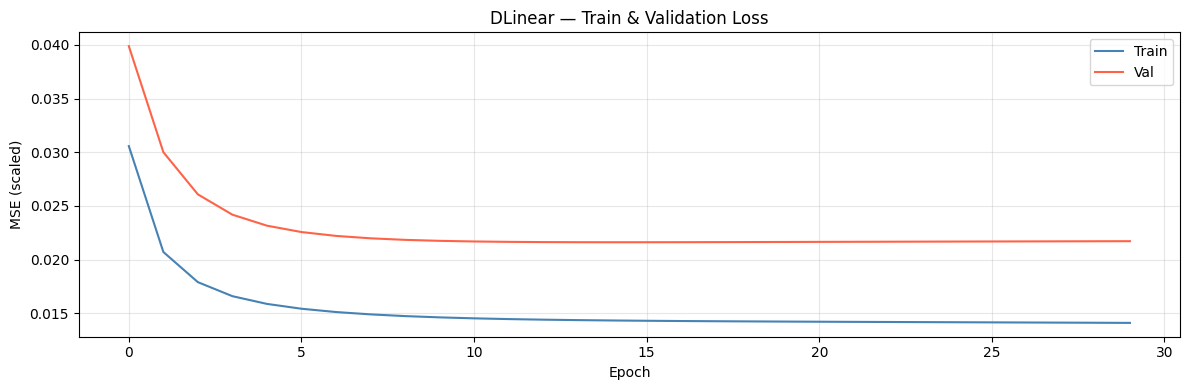

In [15]:
plt.figure(figsize=(12, 4))
plt.title('DLinear — Train & Validation Loss')
plt.plot(history['epoch'], history['train_loss'], label='Train', color='steelblue')
plt.plot(history['epoch'], history['val_loss'], label='Val', color='tomato')
plt.xlabel('Epoch')
plt.ylabel('MSE (scaled)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Test Evaluation (inverse-scaled)

Identical to stable nb cells 108-110.

In [16]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

test_preds, test_targets = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        out = model(X_b.to(device))[:, :, OT_IDX]
        test_preds.extend(out.cpu().numpy())
        test_targets.extend(y_b.numpy())

test_preds = np.array(test_preds)
test_targets = np.array(test_targets)

# Inverse transform — same as stable nb
inv_preds = target_scaler.inverse_transform(test_preds.reshape(-1,1)).reshape(-1,12)
inv_targets = target_scaler.inverse_transform(test_targets.reshape(-1,1)).reshape(-1,12)

mse_val = mean_squared_error(inv_targets.flatten(), inv_preds.flatten())
mae_val = mean_absolute_error(inv_targets.flatten(), inv_preds.flatten())
rmse_val = np.sqrt(mse_val)

print('=' * 60)
print(f'  DLinear + BERT  |  Test MSE : {mse_val:.4f}')
print(f'                  |  Test MAE : {mae_val:.4f}')
print(f'                  |  Test RMSE: {rmse_val:.4f}  (inverse-scaled)')
print(f'  DSA (mean/best) |  Test MSE : 1.120 ± 0.096 / 0.9749')
print('=' * 60)

# ── Per-sample errors for Diebold-Mariano (inverse-scaled, shape (N,)) ────────
per_sample_mse   = ((inv_preds - inv_targets) ** 2).mean(axis=1)   # (N,)
per_horizon_mse  = ((inv_preds - inv_targets) ** 2).mean(axis=0)   # (12,)

np.save(f'{LOG_DIR}/errors_dlinear_bert.npy',  per_sample_mse)   # for DM test
np.save(f'{LOG_DIR}/horizon_dlinear_bert.npy', per_horizon_mse)  # for horizon plot
np.save(f'{LOG_DIR}/preds_dlinear_bert.npy',   inv_preds)        # full predictions
np.save(f'{LOG_DIR}/targets_dlinear_bert.npy', inv_targets)      # ground truth

# ── Per-horizon MSE print ─────────────────────────────────────────────────────
print('\nPer-horizon MSE (weeks 1-12):')
for h, hmse in enumerate(per_horizon_mse, 1):
    print(f'  Week {h:2d}: {hmse:.4f}')

  DLinear + BERT  |  Test MSE : 1.6642
                  |  Test MAE : 0.8216
                  |  Test RMSE: 1.2900  (inverse-scaled)
  DSA (mean/best) |  Test MSE : 1.120 ± 0.096 / 0.9749

Per-horizon MSE (weeks 1-12):
  Week  1: 0.1690
  Week  2: 0.5310
  Week  3: 0.8759
  Week  4: 1.2245
  Week  5: 1.5292
  Week  6: 1.8200
  Week  7: 2.0368
  Week  8: 2.2315
  Week  9: 2.3319
  Week 10: 2.4588
  Week 11: 2.3995
  Week 12: 2.3621


## 13. Prediction vs Ground Truth Plot

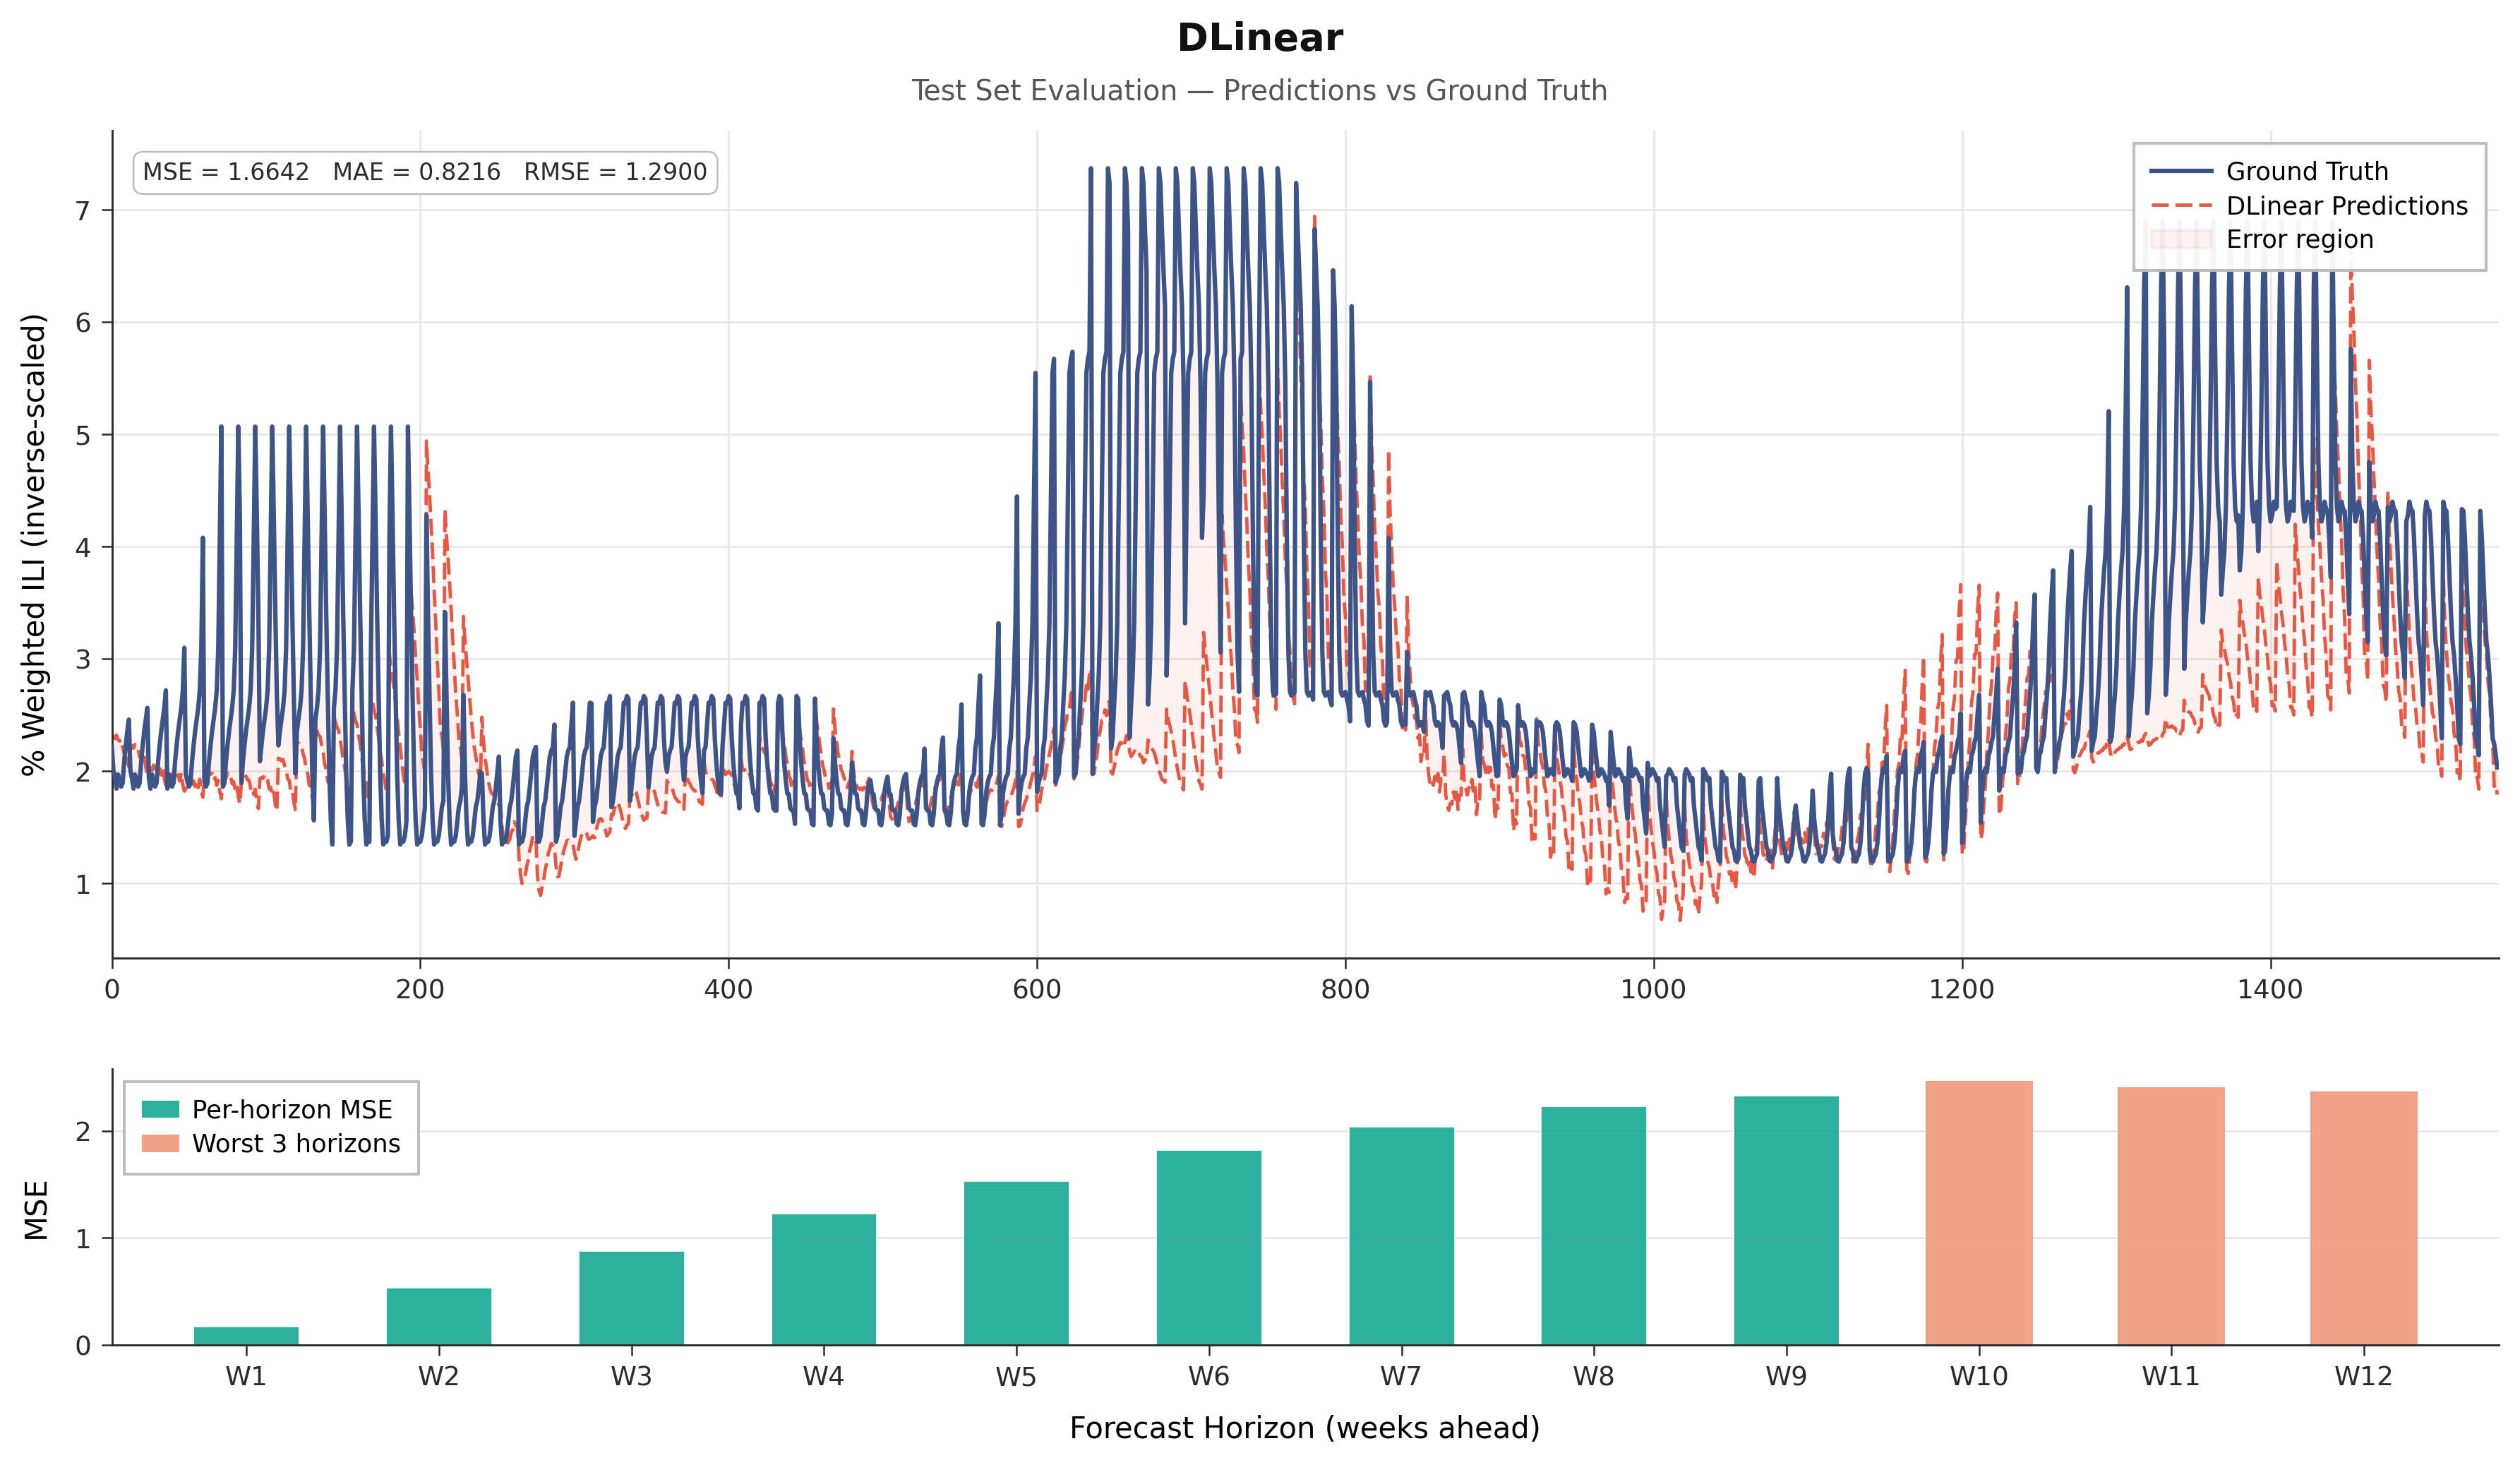

In [17]:
# ── NPG  palette ────────────────────────────────────
C_TRUTH  = '#3C5488'   # deep indigo   — ground truth
C_PRED   = '#E64B35'   # coral red     — predictions
C_FILL   = '#E64B35'   # error fill
C_BAR    = '#00A087'   # teal          — base bars
C_WORST  = '#F39B7F'   # soft salmon   — worst horizons
C_GRID   = '#E5E5E5'

mpl.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':          10,
    'axes.linewidth':     0.7,
    'axes.edgecolor':    '#2B2B2B',
    'axes.facecolor':    'white',
    'figure.facecolor':  'white',
    'xtick.major.width':  0.6, 'ytick.major.width':  0.6,
    'xtick.major.size':   3.5, 'ytick.major.size':   3.5,
    'xtick.direction':   'out', 'ytick.direction':   'out',
    'xtick.color':       '#2B2B2B', 'ytick.color':   '#2B2B2B',
    'legend.framealpha':  0.95, 'legend.edgecolor': '#BBBBBB',
    'legend.fancybox':    False,
})

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 6.5), dpi=300,
    gridspec_kw={'height_ratios': [3, 1]}
)

# ── Two-line title: bold model name + lighter subtitle ────────────────────────
fig.text(0.5, 1.03, 'DLinear',
         ha='center', va='bottom',
         fontsize=13, fontweight='bold', color='#111111')
fig.text(0.5, 0.995, 'Test Set Evaluation — Predictions vs Ground Truth',
         ha='center', va='bottom',
         fontsize=9.5, fontweight='normal', color='#555555')

# ── Panel 1 ───────────────────────────────────────────────────────────────────
flat_targets = inv_targets.flatten()   # (N*12,)
flat_preds   = inv_preds.flatten()     # (N*12,)
timesteps    = np.arange(len(flat_targets))

ax1.plot(timesteps, flat_targets,
         color=C_TRUTH, linewidth=1.5, alpha=1.0,
         label='Ground Truth', zorder=3)
ax1.plot(timesteps, flat_preds,
         color=C_PRED, linewidth=1.15, linestyle='--',
         dashes=(5, 2), alpha=0.92,
         label='DLinear Predictions', zorder=2)
ax1.fill_between(timesteps, flat_targets, flat_preds,
                 color=C_FILL, alpha=0.07, zorder=1, label='Error region')
ax1.set_ylabel('% Weighted ILI (inverse-scaled)', fontsize=10, labelpad=8)
ax1.set_xlim(0, len(flat_targets))
ax1.grid(True, color=C_GRID, linewidth=0.6, linestyle='-')
ax1.set_axisbelow(True)
ax1.spines[['top', 'right']].set_visible(False)
ax1.tick_params(axis='both', labelsize=9)
ax1.legend(loc='upper right', fontsize=8.5, handlelength=2.4,
           handletextpad=0.6, borderpad=0.7, labelspacing=0.4)
ax1.text(0.013, 0.963,
         f'MSE = {mse_val:.4f}   MAE = {mae_val:.4f}   RMSE = {rmse_val:.4f}',
         transform=ax1.transAxes, fontsize=8,
         verticalalignment='top', color='#2B2B2B',
         bbox=dict(boxstyle='round,pad=0.40', facecolor='white',
                   edgecolor='#BBBBBB', linewidth=0.6, alpha=0.97))

# ── Panel 2 ───────────────────────────────────────────────────────────────────
horizon_steps = np.arange(1, 13)
bars = ax2.bar(horizon_steps, per_horizon_mse,
               color=C_BAR, alpha=0.82, width=0.55,
               edgecolor='white', linewidth=0.5, zorder=2)
top3_idx = np.argsort(per_horizon_mse)[-3:]
for idx in top3_idx:
    bars[idx].set_color(C_WORST)
    bars[idx].set_alpha(0.92)
ax2.set_xlabel('Forecast Horizon (weeks ahead)', fontsize=10, labelpad=8)
ax2.set_ylabel('MSE', fontsize=10, labelpad=8)
ax2.set_xticks(horizon_steps)
ax2.set_xticklabels([f'W{h}' for h in horizon_steps], fontsize=8.5)
ax2.grid(axis='y', color=C_GRID, linewidth=0.6, linestyle='-')
ax2.set_axisbelow(True)
ax2.set_xlim(0.3, 12.7)
ax2.tick_params(axis='both', labelsize=9)
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(handles=[
    Patch(facecolor=C_BAR,   alpha=0.82, label='Per-horizon MSE'),
    Patch(facecolor=C_WORST, alpha=0.92, label='Worst 3 horizons'),
], fontsize=8.5, loc='upper left', handlelength=1.5,
   handletextpad=0.5, borderpad=0.7, labelspacing=0.4)

plt.tight_layout(h_pad=2.2)
plt.savefig(f'{LOG_DIR}/dlinear_test_evaluation.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()